# Quantum Portfolio Optimization AMSP 42Stocks Tutorial
## 42 Stocks S&P 500 Universe - Tutorial

This notebook demonstrates the full workflow of the AMSP-based quantum portfolio optimization method with CVaR risk monitoring.

### What You'll Learn:
1. Data Loading: Load and validate 42-stock universe from S&P 500
2. Dynamic Universe: How stocks become eligible based on historical data availability
3. AMSP Methodology: Asset-Matched Sampling Projection for covariance estimation
4. Quantum Optimization: Compare different solver backends
5. Risk Management: CVaR (Conditional Value at Risk) monitoring
6. Sector Diversification: Track sector exposure and concentration (HHI)
7. Performance Analysis: Comprehensive metrics vs SPY benchmark

### Research Methodology:
- **Pure Systematic Strategy**: Zero discretionary decisions
- **Always Invested**: Comparable to passive buy-and-hold (SPY)
- **Dynamic Universe**: Stocks eligible when sufficient historical data available
- **No Survivorship Bias**: Universe expands as new stocks gain history
- **Academic Rigor**: Reproducible, transparent, fair comparison

Click [here](../Tutorial/AMSP_CVaR_42Stocks_Tutorial.ipynb) to skip the math to the python implementation

## 1. Setup and Imports

In [ ]:
import os
import sys
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Qfolio modules
sys.path.append('..')  # Add parent directory
from qfolio.data.DataManager import DataManager
from qfolio.backtesting.PortfolioManager_AMSP import PortfolioManager

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Modules loaded successfully!")

Modules loaded successfully!


## 2. Mathematical Formulation

### Portfolio Optimization Problem

Recall from our first example, [Regular_benchmark_VOO.ipynb](../Tutorial/Regular_benchmark_VOO.ipynb) We solve the mean-variance optimization problem:

$$
\begin{aligned}
\text{min} \quad & \sum_{i=1}^{n}\sum_{j=1}^{n} \sigma_{ij}x_{i}x_{j} - \sum_{i=1}^{n} \overline{r_{i}} x_{i}\\
\text{s.t.} \quad &\sum_{i=1}^{n} x_{i} \leq B, \\
            & x_{i} \geq 0, \quad \text{for } i \in \{1, \dots, n\}.
\end{aligned}
$$

Where:
-   $x$: is the asset. $x=1$ if selected, $x=0$ if not selected.
-   $\sigma \in \mathbb{R}^{N \times N}$: Covariance matrix of returns
-   $\overline{r_{i}}\in \mathbb{R}^N$: Expected return vector
-   $q$: Risk aversion coefficient (higher = more return-seeking)
-   $\lambda$: Budget constraint penalty (we use $\lambda_1 = 10^3$ in our portfolios example)
-   $B$: Total budget ($)

Next, let's expand our example to let $x_{i}$ denote the number of shares of stock $i$ purchased at price $p_{i}$. We have 

$$
\begin{aligned}
    \text{min} \quad  & \sum_{i=1}^{n}\sum_{j=1}^{n} \sigma_{ij}p_{i}x_{i}p_{j}x_{j} - \sum_{i=1}^{n} \overline{r_{i}} p_{i}x_{i}  \\
    \text{s.t.} \quad  &\sum_{i=1}^{n} p_{i}x_{i} \leq B, \\
                & x_{i} \geq 0, \quad \text{for } i \in \{1, \dots, n\}.
\end{aligned}
$$

After applying the binary encoding, we rewrite the whole Hamiltonian as,

$$
H = q(\sum_{i=1}^{n}\sum_{j=1}^{n} \sigma_{ij}s_{i}s_{j}) + \lambda_{1}(\sum_{i=1}s_{i} - B)^{2} - \sum_{i=1}^{n}\overline{r_{i}} s_{i}
$$

where

$$
s_i = 2^{0}x_{i,0} + 2^{1}x_{i,1} + 2^{2}x_{i,2} + \cdots + 2^{m-1}x_{i,m-1},
$$

where $x_{i,j} \in \{0,1\}$ are binary decision variables, and $m$ is the number of binary bits required to represent the maximum allowable value of $s_i$.

## 2.1 Scale to fractional shares by AMSP method.

While this standard binary encoding approach (detailed in our previous work) is effective for small portfolios, it suffers from three critical limitations that motivated the development of the AMSP method:

1.  Uneven Allocation Granularity: Price variability causes inefficient bit usage across assets. For example, a $50 stock might require 8 bits to represent 200 affordable shares, while a $500 stock uses the same 8 bits for only 20 shares, wasting precious qubit resources on expensive stocks while under-representing cheap stocks.

2.  Fractional Shares Not Supported: Standard binary encoding represents only integer share quantities, incompatible with fractional share trading now ubiquitous on modern brokerage platforms (Robinhood, Fidelity, Interactive Brokers, etc.). This limits practical applicability for retail investors.

3.  **Optimizater failure**: If for example, we have 127 shares for all three stocks a,b,c and the total spend is lower then our budget, $B$, the optimizer will buy all 127 integer shares to all three assets all the time, which lose our opportunity to explore more possiblity, and **lose the purpose of the portfolio optimization!**

To address these fundamental limitations of our original example in [Regular_benchmark_VOO.ipynb](../Tutorial/Regular_benchmark_VOO.ipynb), we introduce **Budget-Normalized Binary Encoding (BNBE)**, also called the **Adjusted Maximum Share Price (AMSP) method**.

### 2.2 AMSP method

#### Step 1. Calculate Unifrom Lot price

For binary encoding with $m$ bits per asset and base $k=2$, the maximum representable value is $\sum_{i=0}^{m-1} 2^i = 2^m - 1$. We define the lot price as the budget divided by this maximum sum:

$$
\text{AMSP} = \frac{B}{\sum_{i=0}^{m-1} 2^i} = \frac{B}{2^m - 1}.
$$

For our implementation with $m=7$ bits per asset and budget $B = \$10{,}000$:
$$\text{AMSP} = \frac{10{,}000}{2^7 - 1} = \frac{10{,}000}{127} \approx \$78.74 \text{ per lot}.$$

This uniform price serves as the fundamental unit of investment across all assets.

#### Step 2. Calculate Unifrom Lot price

Each asset $i$ with original market price $p_i$ is converted to a lot-based representation, where one lot contains:

$$
L_i = \frac{\text{AMSP}}{p_i} \quad \text{shares per lot}.
$$

This transformation naturally enables fractional share allocation, addressing Limitation 3. For example, at recent market prices:

*   NVDA at \$500/share: $L_{\text{NVDA}} = 78.74 / 500 = 0.1575$ shares per lot
*   AAPL at \$150/share: $L_{\text{AAPL}} = 78.74 / 150 = 0.5249$ shares per lot
*   TSLA at \$250/share: $L_{\text{TSLA}} = 78.74 / 250 = 0.3150$ shares per lot

#### Step 3: Normalize All Asset Prices

All assets are assigned the uniform lot price, eliminating price heterogeneity:

$$
\tilde{p}_i = \text{AMSP} \quad \text{for all } i \in \{1, \ldots, n\}.
$$

**This addresses Limitation 1 by ensuring equal allocation granularity across all assets.**

#### Step 4: Binary Encoding of Lot Allocations

The number of lots allocated to asset $i$ is encoded using $m$ binary variables:

$$
n_i = \sum_{j=0}^{m-1} 2^{j} x_{i,j}, \quad x_{i,j} \in \{0,1\}, \quad n_i \in \{0, 1, \ldots, 2^m - 1\}.
$$

Note that $n_i$ represents $\text{lots}$, not shares, which is the crucial distinction from standard encoding.

#### Step 5: Compute Actual Share Allocation

The final number of shares of asset $i$ held in the portfolio is:

$$
s_i = n_i \times L_i = n_i \times \frac{\text{AMSP}}{p_i}.
$$

This five-step transformation maps the original price-heterogeneous problem into a price-normalized lot-based problem suitable for quantum optimization.

Therefore, budget violation is *mathematically impossible*. Even in the extreme case where all $21$ binary qubits are assigned to a single asset (e.g., $n_1 = 127, n_2 = 0, n_3 = 0$), the total cost is exactly $127 \times \$78.74 = \$10{,}000.00 = B$. 

### 2.3 Modified QUBO Formulation with AMSP Encoding

#### Step 1. Adjusted Expected Returns

The expected return per lot for asset $i$ becomes:

$$
\tilde{\mu}_i = \mu_i \times L_i = \mu_i \times \frac{\text{AMSP}}{p_i}.
$$

This represents the expected return from investing one lot $(\$78.74)$ in asset $i$, accounting for the fractional shares contained in that lot.

#### Step 2. Adjusted Covariance Matrix

Similarly, the covariance between lot allocations of assets $i$ and $j$ is:

$$
\tilde{\Sigma}_{ij} = \Sigma_{ij} \times L_i \times L_j = \Sigma_{ij} \times \frac{\text{AMSP}}{p_i} \times \frac{\text{AMSP}}{p_j}.
$$

This scaling ensures that risk calculations remain consistent with the lot-based allocation framework, preserving the mean-variance optimization structure.

#### Step 3. AMSP-Encoded Hamiltonian

Substituting the adjusted parameters into the QUBO formulation, the AMSP-encoded Hamiltonian becomes:

$$
\begin{aligned}
H_{\text{AMSP}} &= q \sum_{i=1}^n \sum_{j=1}^n \tilde{\Sigma}_{ij} \cdot n_i \cdot n_j \\
&\quad + \lambda_1 \left( \sum_{i=1}^n n_i - B \right)^2 \\
&\quad - \sum_{i=1}^n \tilde{\mu}_i \cdot n_i,
\end{aligned}
$$

where $n_i$ represents lot allocations (not shares), and all prices have been normalized to AMSP.

---

### 2.4 References for Full Mathematical Details

> **For detailed mathematical derivations and proofs**, see:
> - **AMSP Method**: [Qfolio Paper, Section 3.2](https://github.com/pcchouCR97/Qfolio/blob/main/paper/paper.pdf)
> - **Cardinality Constraints (JPMorgan)**: [arXiv:2409.10301v1, Section III.C.1](https://arxiv.org/abs/2409.10301)
> - **CVaR Risk Measures**: [Rockafellar & Uryasev (2000), Journal of Risk](https://doi.org/10.21314/JOR.2000.038)
> - **Quantum Optimization Framework**: [Qiskit Optimization Documentation](https://qiskit-community.github.io/qiskit-optimization/)

The equations above provide the core formulation needed for implementation. Full proofs and additional technical details are available in the referenced papers.

## 3. Investment Universe Construction

We construct a diversified screening universe of 42 stocks selected from the S\&P 500 index by market cap in 2025 Oct, spanning all 11 GICS sectors:

*   Technology (6): NVDA, MSFT, AAPL, AVGO, ORCL, PLTR
*   Financials (6): BRK.B, JPM, V, BAC, MA, GS
*   Healthcare (5): LLY, JNJ, ABBV, UNH, MRK
*   Consumer Cyclical (4): AMZN, TSLA, HD, MCD
*   Industrials (4): GE, CAT, RTX, GEV
*   Consumer Defensive (4): WMT, PG, COST, KO
*   Communication Services (3): GOOGL, META, NFLX
*   Energy (3): XOM, CVX, COP
*   Materials (2): LIN, APD
*   Utilities (2): NEE, SO
*   Real Estate (2): PLD, AMT

This universe provides sector-diversified exposure while enabling our dynamic selection algorithm to adapt to changing market conditions.

In [ ]:
import os
import sys
import pandas as pd
from pandas.tseries.offsets import BDay
import matplotlib
#matplotlib.use('Agg')  # Non-interactive backend for unattended grid search
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal

# Qfolio modules
sys.path.append('..')  # Add parent directory
from qfolio.data.DataManager import DataManager
from qfolio.backtesting.PortfolioManager_AMSP import PortfolioManager
from data_screener.screener import *
from qfolio.metrics.RiskMetrics import RiskMetricsCalculator # Import the new calculator
from qfolio.results.save_results_module import save_backtest_results
import sys
import numpy as np
import seaborn as sns

In [ ]:
# --- Sector Mapping for 42 Stocks ---
SECTOR_MAPPING = {
    # Technology: 6 stocks
    'NVDA': 'Technology', 'MSFT': 'Technology', 'AAPL': 'Technology',
    'AVGO': 'Technology', 'ORCL': 'Technology', 'PLTR': 'Technology',
    # Financials: 6 stocks
    'BRK.B': 'Financials', 'JPM': 'Financials', 'V': 'Financials',
    'BAC': 'Financials', 'MA': 'Financials', 'GS': 'Financials',
    # Healthcare: 5 stocks
    'LLY': 'Healthcare', 'JNJ': 'Healthcare', 'ABBV': 'Healthcare',
    'UNH': 'Healthcare', 'MRK': 'Healthcare',
    # Consumer Cyclical: 4 stocks
    'AMZN': 'Consumer Cyclical', 'TSLA': 'Consumer Cyclical',
    'HD': 'Consumer Cyclical', 'MCD': 'Consumer Cyclical',
    # Industrials: 4 stocks
    'GE': 'Industrials', 'CAT': 'Industrials', 'RTX': 'Industrials', 'GEV': 'Industrials',
    # Consumer Defensive: 4 stocks
    'WMT': 'Consumer Defensive', 'PG': 'Consumer Defensive',
    'COST': 'Consumer Defensive', 'KO': 'Consumer Defensive',
    # Communication Services: 3 stocks
    'GOOGL': 'Communication', 'META': 'Communication', 'NFLX': 'Communication',
    # Energy: 3 stocks
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy',
    # Materials: 2 stocks
    'LIN': 'Materials', 'SCCO': 'Materials',
    # Utilities: 2 stocks
    'NEE': 'Utilities', 'CEG': 'Utilities',
    # Real Estate: 2 stocks
    'PLD': 'Real Estate', 'WELL': 'Real Estate',
}

In [21]:
# 1. --- Configuration ---
# Load data
data = load_data(path="SP500_42stocks_baseline_adjusted_close.csv")

# Ensure all data columns are numeric, coercing errors
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

sim_start_date = "2020-07-01" # Q3 2020 start
sim_end_date = "2025-08-01" # 5 years total

rebalance_freq = '63B'
training_lookback_days = 120 # check 60, 90, 120, 150, 180
risk_lookback_period = 120 # Lookback for CVaR calculation (needed for data filtering)
exchange = 'NYSE'

initial_budget = 10000
new_invest_per_period = 0
benchmark_assets = ['SPY']

# Full potential universe (all stocks except benchmark)
trading_universe_full = list(data.columns.drop(benchmark_assets))  # All 51 stocks

print(f"All available assets: {data.columns.tolist()}")
print(f"Total assets in data: {len(data.columns)}")
print(f"Potential trading universe: {len(trading_universe_full)} stocks (excluding {benchmark_assets} benchmark)")

# Keep all data (no pre-filtering - dynamic filtering happens at each rebalance)
all_needed_assets = trading_universe_full + benchmark_assets
data = data[all_needed_assets]

# Dynamic universe: will be updated at each rebalance date based on data availability 
# Initial universe will be determined at first rebalance date based on data availability
print(f"\nUsing DYNAMIC UNIVERSE approach:")
print(f"  - Stocks become eligible when they have {training_lookback_days + risk_lookback_period} days of history")
print(f"  - Universe checked at each rebalance (every {rebalance_freq})")
print(f"  - Follows MSCI index methodology for new stock inclusion\n")

# --- Optimization Parameters ---
k = 2
lambda1 = 1E12 
q = 1E-3
H_scale = 1E5 
solver_type = 'QAOA' # 'classic', 'QAOA', 'QAOA_shots', 'SamplerVQE'

# --- Risk Manager Parameters ---
sharpe_n = 3
confidence_level = 0.95
# Note: risk_lookback_period defined earlier for data filtering


Loading data from: SP500_42stocks_baseline_adjusted_close.csv
All available assets: ['NVDA', 'MSFT', 'AAPL', 'AVGO', 'ORCL', 'PLTR', 'BRK.B', 'JPM', 'V', 'BAC', 'MA', 'GS', 'LLY', 'JNJ', 'ABBV', 'UNH', 'ABT', 'AMZN', 'TSLA', 'HD', 'MCD', 'GE', 'CAT', 'RTX', 'GEV', 'WMT', 'COST', 'PG', 'KO', 'GOOGL', 'META', 'NFLX', 'XOM', 'CVX', 'COP', 'LIN', 'SCCO', 'NEE', 'CEG', 'WELL', 'PLD', 'SPY']
Total assets in data: 42
Potential trading universe: 41 stocks (excluding ['SPY'] benchmark)

Using DYNAMIC UNIVERSE approach:
  - Stocks become eligible when they have 240 days of history
  - Universe checked at each rebalance (every 63B)
  - Follows MSCI index methodology for new stock inclusion



In [22]:
# ============================================================================
# AUTOMATED MULTI-SOLVER COMPARISON FRAMEWORK
# ============================================================================

# Define solvers to test
SOLVERS_TO_RUN = ['classic', 'QAOA', 'QAOA_shots', 'SamplerVQE']

# Storage for all solver results  
all_solver_results = {}

# Create output directory
os.makedirs("tutorial_results", exist_ok=True)

print("="*80)
print("AUTOMATED MULTI-SOLVER COMPARISON")
print(f"Will run {len(SOLVERS_TO_RUN)} solvers: {', '.join(SOLVERS_TO_RUN)}")
print(f"Output directory: tutorial_results/")
print("="*80)

AUTOMATED MULTI-SOLVER COMPARISON
Will run 4 solvers: classic, QAOA, QAOA_shots, SamplerVQE
Output directory: tutorial_results/


## 5. Main Solver Loop: Run All Solvers Sequentially

The following cell runs the complete backtest simulation for each solver. This includes:

1. **Market calendar setup** with NYSE trading days
2. **Initial universe determination** (stocks with sufficient history)
3. **Daily simulation loop** with:
   - Portfolio valuation each trading day
   - CVaR risk monitoring (for analysis only)
   - Rebalancing on scheduled dates (every 63 business days)
   - Dynamic universe expansion as new stocks gain sufficient history
   - Portfolio composition and turnover tracking
   - Sector exposure and HHI concentration tracking

4. **Results processing** for each solver:
   - ROI calculation vs invested capital
   - SPY benchmark comparison
   - Comprehensive performance metrics (30+ indicators)
   - Statistical significance testing

**Note**: This cell may take 10-30 minutes to complete depending on your system. Progress will be printed for each solver.

## 4. Automated Multi-Solver Comparison Framework

This notebook automatically runs multiple quantum and classical solvers to compare their performance. The following solvers will be tested:

- **classic**: NumPy eigenvalue solver (exact solution, baseline)
- **QAOA**: Quantum Approximate Optimization Algorithm (statevector simulation)
- **QAOA_shots**: QAOA with shot-based sampling (more realistic quantum simulation)
- **SamplerVQE**: Variational Quantum Eigensolver with sampling (TwoLocal ansatz)

Each solver will produce:
- Portfolio values and ROI time series
- Comprehensive performance metrics (30+ metrics)
- Composition and turnover history
- Sector exposure and concentration analysis
- Full QuantStats HTML tearsheet report

In [ ]:
# --- Dynamic Universe Helper Function ---
def get_eligible_stocks(current_date, all_stocks, data, lookback_days=240):
    """
    Returns stocks with sufficient historical data as of current_date.

    Following MSCI index methodology: stocks are eligible for selection once they
    have sufficient trading history for the required lookback window.

    Parameters:
    -----------
    current_date : pd.Timestamp
        The date at which to evaluate eligibility
    all_stocks : list
        Full list of potential stocks to evaluate
    data : pd.DataFrame
        Price data with stocks as columns
    lookback_days : int
        Minimum number of business days of history required

    Returns:
    --------
    eligible : list 
        Stock tickers that have sufficient history
    """
    min_required_date = current_date - BDay(lookback_days)
    first_valid_dates = data[all_stocks].apply(lambda x: x.first_valid_index())
    eligible = first_valid_dates[first_valid_dates <= min_required_date].index.tolist()
    return eligible

def calculate_sector_concentration(sector_weights):
    """
    Calculate Herfindahl-Hirschman Index for sector concentration.

    HHI = sum of squared weights (in decimal form) * 100
    - 100 = single sector (maximum concentration)
    - <15 = diversified (per DOJ antitrust guidelines)
    - 15-25 = moderate concentration
    - \> 25 = high concentration

    For example, a portfolio with 50% in Tech, 30% in Health, 20% in Finance:
    HHI = (0.5^2 + 0.3^2 + 0.2^2) * 100 = (0.25 + 0.09 + 0.04) * 100 = 38   

    Parameters:
    -----------
    sector_weights : dict
        {sector: weight_percentage}

    Returns:
    --------
    float : HHI value
    """
    weights_squared = [(w/100)**2 for w in sector_weights.values() if w > 0]
    hhi = sum(weights_squared) * 100
    return hhi

def calculate_sector_exposure(allocation, prices):
    """
    Calculate portfolio value distribution by sector.

    Parameters:
    -----------
    allocation : dict
        {ticker: shares} mapping
    prices : dict
        {ticker: price} mapping

    Returns:
    --------
    dict : {sector: weight_percentage}
    """
    total_value = sum(allocation.get(t, 0) * prices.get(t, 0) for t in allocation)
    if total_value == 0:
        return {}

    sector_values = {}
    for ticker, shares in allocation.items():
        sector = SECTOR_MAPPING.get(ticker, 'Unknown')
        value = shares * prices.get(ticker, 0)
        sector_values[sector] = sector_values.get(sector, 0) + value

    return {sector: (value / total_value) * 100 for sector, value in sector_values.items()}


In [24]:
# 2. --- Setup with Market Calendar ---
market_cal = mcal.get_calendar(exchange)
data_start_date_for_calendar = (pd.to_datetime(sim_start_date) - BDay(training_lookback_days + risk_lookback_period + 5)).strftime('%Y-%m-%d')
full_schedule = market_cal.schedule(start_date=data_start_date_for_calendar, end_date=sim_end_date)
all_trading_days = full_schedule.index

approx_rebalance_dates = pd.date_range(start=sim_start_date, end=sim_end_date, freq=rebalance_freq)
rebalance_indices = all_trading_days.searchsorted(approx_rebalance_dates, side='left')
rebalance_indices = rebalance_indices[rebalance_indices < len(all_trading_days)]
actual_rebalance_dates = all_trading_days[rebalance_indices]

# Get initial eligible universe
initial_train_end_loc = all_trading_days.get_loc(actual_rebalance_dates[0]) - 1
initial_train_end = all_trading_days[initial_train_end_loc]
initial_train_start_loc = initial_train_end_loc - training_lookback_days
if initial_train_start_loc < 0: initial_train_start_loc = 0
initial_train_start = all_trading_days[initial_train_start_loc]

# Determine initial eligible stocks based on data availability
initial_eligible_stocks = get_eligible_stocks(
    current_date=initial_train_end,
    all_stocks=trading_universe_full,
    data=data,
    lookback_days=training_lookback_days + risk_lookback_period
)

print(f"Initial eligible universe (as of {initial_train_end.strftime('%Y-%m-%d')}): {len(initial_eligible_stocks)} stocks")
print(f"  Stocks: {initial_eligible_stocks}\n")

# Calculate initial Sharpe ratios on eligible stocks only
data_for_initial_screening = data[initial_eligible_stocks]
initial_sharpe_results = SharpeRatioCalculator(data_for_initial_screening, initial_train_start.strftime('%Y-%m-%d'),
initial_train_end.strftime('%Y-%m-%d'), risk_free=0.0, print_out=False)

initial_positive_mean_returns = initial_sharpe_results['r_i_series'][initial_sharpe_results['r_i_series'] > 0]
if not initial_positive_mean_returns.empty:
    initial_candidate_sharpes = initial_sharpe_results['sharpe_series'][initial_positive_mean_returns.index]
    initial_assets = initial_candidate_sharpes.dropna().sort_values(ascending=False).head(sharpe_n).index.tolist()
else:
    initial_assets = []

# Initialize PortfolioManager with initial eligible universe
PM = PortfolioManager(data=data[initial_eligible_stocks],
                    budget=initial_budget,
                    new_invest=new_invest_per_period,
                    assets_portfolio=initial_assets,
                    assets_benchmark=benchmark_assets,
                    screener=SharpeRatioCalculator)

Initial eligible universe (as of 2020-06-30): 38 stocks
  Stocks: ['NVDA', 'MSFT', 'AAPL', 'AVGO', 'ORCL', 'BRK.B', 'JPM', 'V', 'BAC', 'MA', 'GS', 'LLY', 'JNJ', 'ABBV', 'UNH', 'ABT', 'AMZN', 'TSLA', 'HD', 'MCD', 'GE', 'CAT', 'RTX', 'WMT', 'COST', 'PG', 'KO', 'GOOGL', 'META', 'NFLX', 'XOM', 'CVX', 'COP', 'LIN', 'SCCO', 'NEE', 'WELL', 'PLD']



In [ ]:
# 3. --- Main Simulation Loop (Daily) ---

portfolio_history = []
current_budget = initial_budget
last_allocation = {}
portfolio_high_value = initial_budget
all_rebalance_events = [] # Track all rebalance dates
is_first_rebalance = True  # Track first rebalance to exclude new investment
previous_eligible_stocks = initial_eligible_stocks  # Track universe changes

# --- New Tracking Variables for Enhanced Analytics ---
composition_history = []  # Track which stocks selected at each rebalance
turnover_history = []  # Track portfolio turnover at each rebalance
previous_allocation = {}  # For turnover calculation
sector_exposure_history = []  # Track sector weights at each rebalance
concentration_history = []  # Track sector concentration (HHI) over time

simulation_days = all_trading_days[all_trading_days.slice_indexer(sim_start_date, sim_end_date)]

print(f"\n--- Starting Step-by-Step Simulation Using '{{exchange}}' Calendar ---")
for i, current_date in enumerate(simulation_days):

    # Calculate portfolio value for the current day
    if last_allocation and (current_date in data.index):
        prices_today = data.loc[current_date].to_dict() 
        # https://www.w3schools.com/python/ref_dictionary_get.asp get ticker value, otherwise 0
        current_portfolio_value = sum(last_allocation.get(ticker, 0) * prices_today.get(ticker, 0) for ticker in last_allocation) # Update portfolio value based on current prices
    else:
        current_portfolio_value = current_budget

    portfolio_high_value = max(portfolio_high_value, current_portfolio_value) # record high value
    portfolio_history.append({'date': current_date, 'value': current_portfolio_value, 'allocation': last_allocation})

    # --- CVaR Risk Monitoring (For Analysis Only - Does Not Trigger Trades) ---
    if last_allocation:
        try:
            risk_calc = RiskMetricsCalculator(
                portfolio_allocation=last_allocation,
                price_data=data,
                current_date=current_date,
                lookback_period=risk_lookback_period
            )
            portfolio_risk = risk_calc.calculate_portfolio_metrics(confidence_level=confidence_level, method='historical')
            cvar_95 = portfolio_risk['CVaR']
            var_95 = portfolio_risk['VaR']

            # MONITORING ONLY - print if risk is elevated, but don't act on it
            if cvar_95 < -0.10:  # Only warn if risk is significant
                print(f"  [RISK MONITOR] {current_date.strftime('%Y-%m-%d')}: CVaR = {cvar_95:.2%}, VaR = {var_95:.2%}")
        except Exception as e:
            pass  # Silent failure for monitoring

    # --- Rebalancing Logic (Only on Scheduled Dates) ---
    is_regular_rebalance = current_date in actual_rebalance_dates

    if is_regular_rebalance:
        all_rebalance_events.append(current_date)
        current_budget_for_opt = current_portfolio_value

        # Only add new investment after the first rebalance, i.e. not at initial setup. For example, if initial budget is $10,000 and new investment is $1,000 per period,
        # at the first rebalance we only use the current portfolio value of $10,000
        if not is_first_rebalance:
            current_budget_for_opt += new_invest_per_period
            print(f"--- Rebalancing on {current_date.strftime('%Y-%m-%d')} --- (Budget: ${current_portfolio_value:.2f} + New Investment: ${new_invest_per_period:.2f} = ${current_budget_for_opt:.2f})")
        else:
            print(f"--- First Rebalancing on {current_date.strftime('%Y-%m-%d')} --- (Initial Budget: ${current_budget_for_opt:.2f})")
            is_first_rebalance = False

        # Determine training window
        current_date_loc = all_trading_days.get_loc(current_date)
        train_end_loc = current_date_loc - 1 # we train up to day before current date (rebalance day)
        if train_end_loc < 0: # not enough data
            print("Not enough historical data to train. Skipping rebalance.")
            continue
        train_end = all_trading_days[train_end_loc] # locate train end date, format: pd.Timestamp
        train_start_loc = train_end_loc - training_lookback_days # training lookback
        if train_start_loc < 0: train_start_loc = 0 # if not enough data, start from beginning, first date
        train_start = all_trading_days[train_start_loc] # locate train start date, format: pd.Timestamp

        # --- DYNAMIC UNIVERSE: Update eligible stocks based on data availability ---
        # Eligible stocks will be added into the universe if have enough history
        current_eligible_stocks = get_eligible_stocks(
            current_date=train_end,
            all_stocks=trading_universe_full,
            data=data,
            lookback_days=training_lookback_days + risk_lookback_period
        ) # get a list of eligible stocks

        # Check for universe expansion
        if len(current_eligible_stocks) > len(previous_eligible_stocks):
            new_stocks = set(current_eligible_stocks) - set(previous_eligible_stocks) # isolate new stocks
            print(f"  [UNIVERSE EXPANSION] +{len(new_stocks)} new stocks now eligible: {sorted(new_stocks)}, Total eligible stocks: {len(current_eligible_stocks)}")
            previous_eligible_stocks = current_eligible_stocks # update for next check

        # Screen assets from current eligible universe, get their Sharpe ratios
        data_for_screening = data[current_eligible_stocks] # get all eligible stocks data
        current_sharpe_results = SharpeRatioCalculator(data_for_screening, train_start.strftime('%Y-%m-%d'),
                                                        train_end.strftime('%Y-%m-%d'), risk_free=0.0, print_out=False) # get the top sharpe assets

        # Select top N assets from eligible universe
        positive_mean_returns = current_sharpe_results['r_i_series'][current_sharpe_results['r_i_series'] > 0]
        if not positive_mean_returns.empty:
            candidate_sharpes = current_sharpe_results['sharpe_series'][positive_mean_returns.index]
            selected_assets = candidate_sharpes.dropna().sort_values(ascending=False).head(sharpe_n).index.tolist()
        else:
            selected_assets = []

        # Update PM with selected assets
        PM.assets_portfolio = selected_assets

        print(f"Screening for top assets between {train_start.strftime('%Y-%m-%d')} and {train_end.strftime('%Y-%m-%d')}...")
        print(f"New top assets selected: {selected_assets}")
        
        # If no assets selected, maintain previous allocation
        if not PM.assets_portfolio:
            print("--- No assets with positive Sharpe. Maintaining previous allocation. ---")
            if last_allocation:
                # Keep previous allocation, just update value with current prices
                current_portfolio_value = sum(
                    last_allocation.get(ticker, 0) * data.loc[current_date, ticker]
                    for ticker in last_allocation if ticker in data.columns
                )
                portfolio_history[-1]['value'] = current_portfolio_value
            continue
        
        # If all selected assets have negative expected returns, maintain previous allocation
        # expected returns of selected assets, of course you can use different methods for the return modle.
        selected_assets_r_i = current_sharpe_results["r_i_series"].loc[PM.assets_portfolio] # locate expected returns of selected assets
        if all(selected_assets_r_i < 0): 
            print("--- All selected assets have negative expected returns. Maintaining previous allocation. ---")
            if last_allocation:
                # Keep previous allocation, just update value with current prices
                current_portfolio_value = sum(
                    last_allocation.get(ticker, 0) * data.loc[current_date, ticker]
                    for ticker in last_allocation if ticker in data.columns
                )
                portfolio_history[-1]['value'] = current_portfolio_value
            continue
    
        # Update PM data with new eligible stocks
        PM.data = data[PM.assets_portfolio]

        # Run optimization with current eligible stocks
        opt_result = PM.run_single_optimization(
            current_date=current_date.strftime('%Y-%m-%d'),
            train_start=train_start.strftime('%Y-%m-%d'),
            train_end=train_end.strftime('%Y-%m-%d'),
            budget=current_budget_for_opt,
            k=k, lambda1=lambda1, q=q, H_scale=H_scale, solver_type=solver_type,
            latest_open_prices=data.loc[current_date].to_dict()
        )
        last_allocation = opt_result['allocation']
        portfolio_history[-1]['allocation'] = last_allocation
        portfolio_history[-1]['value'] = opt_result['value']
        portfolio_high_value = opt_result['value']

        # --- Track Portfolio Composition ---
        composition_history.append({
            'date': current_date,
            'assets': selected_assets.copy(),
            'num_assets': len(last_allocation),
            'allocation_dict': last_allocation.copy()
        })

        # --- Calculate and Track Turnover ---
        if previous_allocation:
            # Calculate portfolio values
            old_value = sum(previous_allocation.get(t, 0) * data.loc[current_date, t]
                          for t in previous_allocation if t in data.columns)
            new_value = sum(last_allocation.get(t, 0) * data.loc[current_date, t]
                          for t in last_allocation if t in data.columns)

            # Turnover = sum of absolute changes in weights
            turnover = 0
            all_tickers = set(list(previous_allocation.keys()) + list(last_allocation.keys()))
            for ticker in all_tickers:
                if ticker not in data.columns:
                    continue
                old_weight = (previous_allocation.get(ticker, 0) * data.loc[current_date, ticker] / old_value) if old_value > 0 else 0
                new_weight = (last_allocation.get(ticker, 0) * data.loc[current_date, ticker] / new_value) if new_value > 0 else 0
                turnover += abs(new_weight - old_weight)

            turnover_history.append({'date': current_date, 'turnover': turnover * 100})
            print(f"  Portfolio Turnover: {turnover*100:.2f}%")

        previous_allocation = last_allocation.copy()

        # --- Track Sector Exposure ---
        if last_allocation:
            sector_exp = calculate_sector_exposure(last_allocation, data.loc[current_date].to_dict())
            sector_exposure_history.append({'date': current_date, **sector_exp})

            # Calculate concentration
            hhi = calculate_sector_concentration(sector_exp)
            concentration_history.append({
                'date': current_date,
                'HHI': hhi,
                'num_sectors': len(sector_exp)
            })

            print(f"  Sector Exposure: {', '.join([f'{s}: {w:.1f}%' for s, w in sorted(sector_exp.items(), key=lambda x: x[1], reverse=True)])}")
            print(f"  Sector HHI: {hhi:.1f} ({len(sector_exp)} sectors)")

        print(f"End of Rebalance Period. Portfolio Value: ${opt_result['value']:.2f}")

print("--- Simulation Complete ---")


--- Starting Step-by-Step Simulation Using '{exchange}' Calendar ---
--- First Rebalancing on 2020-07-01 --- (Initial Budget: $10000.00)
Screening for top assets between 2020-01-08 and 2020-06-30...
New top assets selected: ['TSLA', 'AMZN', 'NVDA']
--- Running optimization for period starting 2020-07-01 ---
Assets passed to optimizer: ['TSLA', 'AMZN', 'NVDA']
[DEBUG] Shape of train_data for optimization: (121, 3)
78.74015748031496
Mean Period Returns Vector (r_i):
 [0.00901363 0.00190127 0.04019494]

Covariance Matrix (sigma):
 [[0.00441867 0.00044624 0.01320772]
 [0.00044624 0.00019746 0.00364067]
 [0.01320772 0.00364067 0.13992902]]
78.74015748031496
 --- Starting QAOA for 21 qubits --- 
Expected binary solution size: 21
Actual binary solution size: 21 (should be the same as 'Expected binary solution size')
Number of binary bit used: 7

----- Portfolio Share Allocation on 2020-07-01-----
TSLA: 94.94137581024553 shares @ Price 74.642
AMZN: 12.035178827713406 shares @ Price 143.935
NV


                              COMPREHENSIVE PERFORMANCE COMPARISON

Metric                                   Optimized (QAOA)       SPY Benchmark         
------------------------------------------------------------------------------------------

                                     RETURNS & GROWTH                                     
Total Return (%)                                       683.53%               115.10%
CAGR (%)                                                50.12%                16.32%
Alpha (annualized %)                                  7610.88%                 0.00%

                                       RISK METRICS                                       
Volatility (annual %)                                   31.99%                17.45%
Beta                                                     0.94                  1.00
R-Squared                                                0.26                  1.00
Max Drawdown (%)                                       -29.21

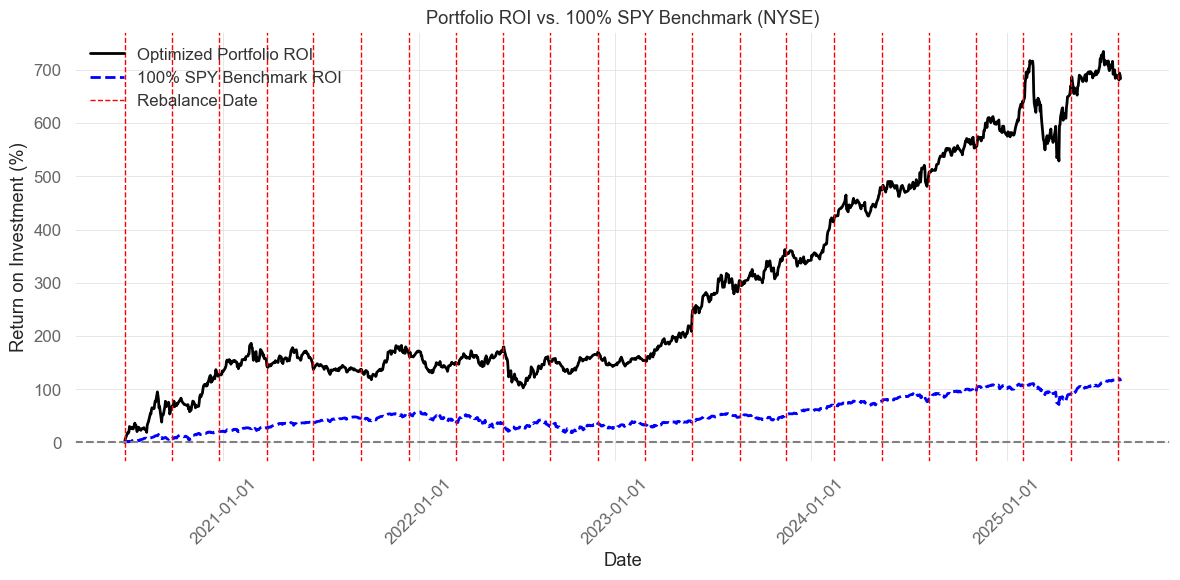

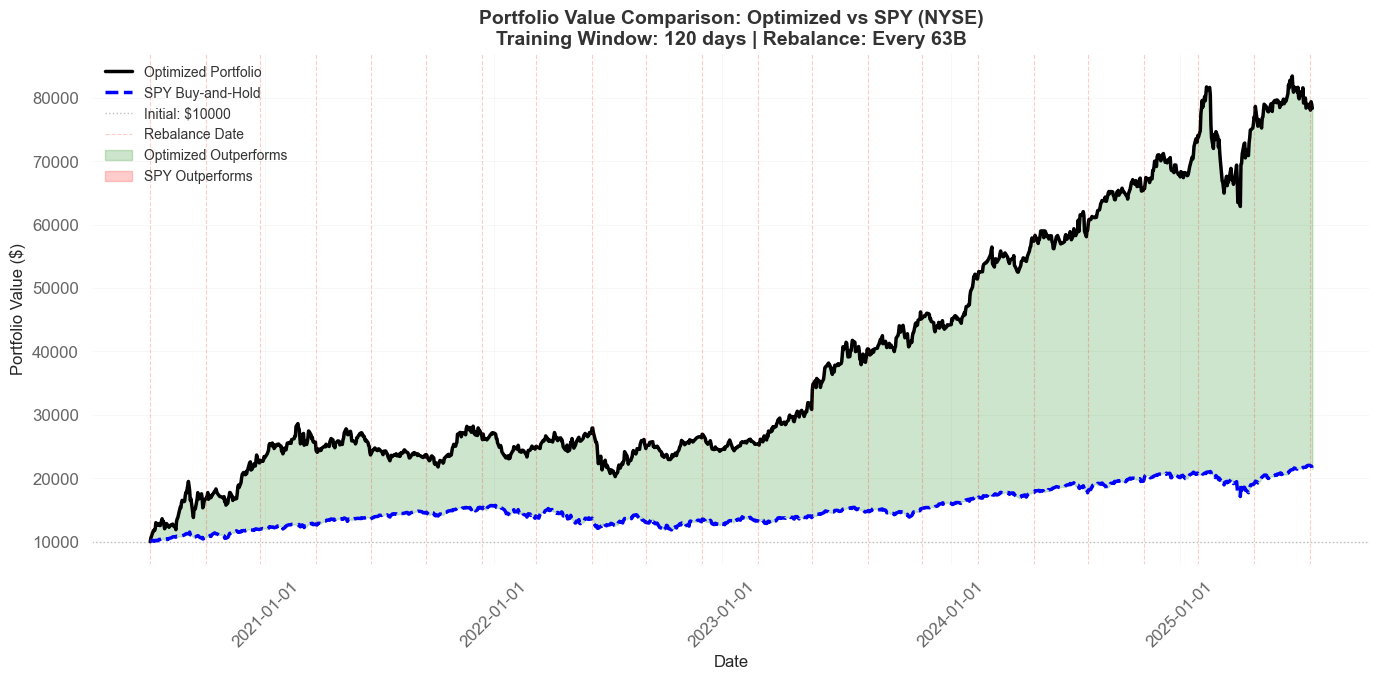

In [26]:
# 4. --- Results and Plotting ---
if not portfolio_history:
    print("Simulation did not produce any results.")
    sys.exit()

# --- Process Optimized Portfolio Results ---
opt_res_df = pd.DataFrame(portfolio_history)
opt_res_df['date'] = pd.to_datetime(opt_res_df['date'])
opt_res_df = opt_res_df.set_index('date')['value'] # Series of portfolio values

# Calculate ROI for Optimized Portfolio
invested_series_opt = pd.Series(0.0, index=opt_res_df.index)
if not opt_res_df.empty:
    # Initial investment
    invested_series_opt.iloc[0] = initial_budget

    # Subsequent investments on scheduled rebalance dates (skip first one)
    for idx, date in enumerate(actual_rebalance_dates):
        if date in invested_series_opt.index and idx > 0:  # Skip first rebalance (idx=0)
            invested_series_opt[date] += new_invest_per_period

    invested_series_opt = invested_series_opt.cumsum()

roi_optimized = ((opt_res_df - invested_series_opt) / invested_series_opt) * 100

# --- Process SPY Benchmark Results (NEW: Daily Tracking) ---
from DailyBenchmarkSimulator import DailyBenchmarkSimulator
spy_benchmark = DailyBenchmarkSimulator(
    assets=['SPY'],
    data=data,
    init_budget=initial_budget,
    new_investment=new_invest_per_period
)

# Run daily simulation with same rebalance dates as optimized portfolio
spy_daily_values, spy_daily_roi = spy_benchmark.simulate(
    start_date=sim_start_date,
    end_date=sim_end_date,
    rebalance_dates=actual_rebalance_dates  # Same dates as optimized portfolio!
)

# Extract SPY series for compatibility
spy_bm_results = spy_daily_roi['SPY']
spy_values = spy_daily_values['SPY']

# --- Calculate Performance Statistics ---
# Optimized Portfolio Statistics
opt_daily_returns = opt_res_df.pct_change().dropna()
opt_total_return = roi_optimized.iloc[-1]
opt_volatility = opt_daily_returns.std() * np.sqrt(252) * 100
opt_sharpe = (opt_daily_returns.mean() / opt_daily_returns.std()) * np.sqrt(252) if opt_daily_returns.std() > 0 else 0

# Calculate max drawdown for optimized portfolio
opt_cumulative = (1 + opt_daily_returns).cumprod()
opt_running_max = opt_cumulative.cummax()
opt_drawdown = (opt_cumulative - opt_running_max) / opt_running_max
opt_max_drawdown = opt_drawdown.min() * 100

# Win rate for optimized portfolio
opt_win_rate = (opt_daily_returns > 0).sum() / len(opt_daily_returns) * 100 if len(opt_daily_returns) > 0 else 0

# Days in market (not in cash)
days_in_market = sum(1 for record in portfolio_history if len(record['allocation']) > 0)
total_days = len(portfolio_history)

# SPY Statistics (using built-in method)
spy_stats = spy_benchmark.get_statistics(spy_daily_values, spy_daily_roi)['SPY']
spy_daily_returns = spy_daily_values['SPY'].pct_change().dropna()
spy_total_return = spy_stats['Total Return (%)']
spy_volatility = spy_stats['Volatility (%)']
spy_sharpe = spy_stats['Sharpe Ratio']
spy_max_drawdown = spy_stats['Max Drawdown (%)']
spy_win_rate = spy_stats['Win Rate (%)']

# --- Upside/Downside Capture Ratios ---
market_up_days = spy_daily_returns > 0
market_down_days = spy_daily_returns < 0

if market_up_days.sum() > 0:
    opt_returns_market_up = opt_daily_returns[market_up_days].mean() * 252
    spy_returns_market_up = spy_daily_returns[market_up_days].mean() * 252
    upside_capture = (opt_returns_market_up / spy_returns_market_up) * 100 if spy_returns_market_up != 0 else 0
else:
    upside_capture = 0

if market_down_days.sum() > 0:
    opt_returns_market_down = opt_daily_returns[market_down_days].mean() * 252
    spy_returns_market_down = spy_daily_returns[market_down_days].mean() * 252
    downside_capture = (opt_returns_market_down / spy_returns_market_down) * 100 if spy_returns_market_down != 0 else 0
else:
    downside_capture = 0

capture_ratio = upside_capture / abs(downside_capture) if downside_capture != 0 else 0

# --- Drawdown Duration Analysis ---
# For optimized portfolio
underwater = opt_drawdown < 0
if underwater.any():
    underwater_groups = (underwater != underwater.shift()).cumsum()
    drawdown_durations = underwater[underwater].groupby(underwater_groups).size()
    max_drawdown_days = drawdown_durations.max()
    avg_drawdown_days = drawdown_durations.mean()
else:
    max_drawdown_days = 0
    avg_drawdown_days = 0

# For SPY
spy_cumulative = (1 + spy_daily_returns).cumprod()
spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max
spy_underwater = spy_drawdown < 0
if spy_underwater.any():
    spy_underwater_groups = (spy_underwater != spy_underwater.shift()).cumsum()
    spy_drawdown_durations = spy_underwater[spy_underwater].groupby(spy_underwater_groups).size()
    spy_max_drawdown_days = spy_drawdown_durations.max()
    spy_avg_drawdown_days = spy_drawdown_durations.mean()
else:
    spy_max_drawdown_days = 0
    spy_avg_drawdown_days = 0

# We use quantstats for additional advanced metrics
import quantstats as qs

# --- Calculate ALL Key Metrics ---
#========= optimized portfolio metrics =========#
# 1. Alpha & Beta (CRITICAL!)
greeks = qs.stats.greeks(opt_daily_returns, spy_daily_returns)
opt_alpha = greeks['alpha'] * 252 * 100  # Annualized in %
opt_beta = greeks['beta']

# 2. R-Squared
opt_r2 = qs.stats.r_squared(opt_daily_returns, spy_daily_returns)

# 3. Treynor Ratio (manual calculation)
opt_treynor = (opt_daily_returns.mean() * 252) / opt_beta if opt_beta != 0 else 0

# 4. Already in previous list
opt_sortino = qs.stats.sortino(opt_daily_returns)
opt_calmar = qs.stats.calmar(opt_daily_returns)
opt_cagr = qs.stats.cagr(opt_daily_returns) * 100
opt_information_ratio = qs.stats.information_ratio(opt_daily_returns, spy_daily_returns)

# 5. Additional metrics
opt_omega = qs.stats.omega(opt_daily_returns)
opt_gain_to_pain = qs.stats.gain_to_pain_ratio(opt_daily_returns)
opt_payoff = qs.stats.payoff_ratio(opt_daily_returns)
opt_profit_factor = qs.stats.profit_factor(opt_daily_returns)
opt_max_drawdown = qs.stats.max_drawdown(opt_daily_returns) * 100
opt_recovery_factor = qs.stats.recovery_factor(opt_daily_returns)
opt_tail_ratio = qs.stats.tail_ratio(opt_daily_returns)
opt_skew = qs.stats.skew(opt_daily_returns)
opt_kurtosis = qs.stats.kurtosis(opt_daily_returns)

#========== SPY portfolio metrics =========#
# 1. Alpha & Beta (CRITICAL!)
spy_greeks = qs.stats.greeks(spy_daily_returns, spy_daily_returns)
spy_alpha = spy_greeks['alpha'] * 252 * 100  # Annualized in %
spy_beta = spy_greeks['beta']

# 2. R-Squared
spy_r2 = qs.stats.r_squared(spy_daily_returns, spy_daily_returns)

# 3. Treynor Ratio (manual calculation)
spy_treynor = (spy_daily_returns.mean() * 252) / opt_beta if opt_beta != 0 else 0

# 4. Already in previous list
spy_sortino = qs.stats.sortino(spy_daily_returns)
spy_calmar = qs.stats.calmar(spy_daily_returns)
spy_cagr = qs.stats.cagr(spy_daily_returns) * 100
spy_information_ratio = qs.stats.information_ratio(spy_daily_returns, spy_daily_returns)

# 5. Additional metrics
spy_omega = qs.stats.omega(spy_daily_returns)
spy_gain_to_pain = qs.stats.gain_to_pain_ratio(spy_daily_returns)
spy_payoff = qs.stats.payoff_ratio(spy_daily_returns)
spy_profit_factor = qs.stats.profit_factor(spy_daily_returns)
spy_max_drawdown = qs.stats.max_drawdown(spy_daily_returns) * 100
spy_recovery_factor = qs.stats.recovery_factor(spy_daily_returns)
spy_tail_ratio = qs.stats.tail_ratio(spy_daily_returns)
spy_skew = qs.stats.skew(spy_daily_returns)
spy_kurtosis = qs.stats.kurtosis(spy_daily_returns)

# --- Statistical Significance Tests ---
from scipy import stats

excess_returns = opt_daily_returns - spy_daily_returns
t_stat, p_value = stats.ttest_1samp(excess_returns.dropna(), 0)

# Interpretation
if p_value < 0.01:
    significance = "*** (Highly Significant)"
elif p_value < 0.05:
    significance = "** (Significant)"
elif p_value < 0.1:
    significance = "* (Marginally Significant)"
else:
    significance = "(Not Significant)"

# --- Print Comprehensive Comparison ---
print("\n" + "="*90)
print(" " * 30 + "COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*90)
print(f"\n{'Metric':<40} {f'Optimized ({solver_type})':<22} {'SPY Benchmark':<22}")
print("-"*90)

# === RETURNS ===
print("\n" + "RETURNS & GROWTH".center(90, " "))
print(f"{'Total Return (%)':<40} {opt_total_return:>20.2f}% {spy_total_return:>20.2f}%")
print(f"{'CAGR (%)':<40} {opt_cagr:>20.2f}% {spy_cagr:>20.2f}%")
print(f"{'Alpha (annualized %)':<40} {opt_alpha:>20.2f}% {spy_alpha:>20.2f}%")

# === RISK ===
print("\n" + "RISK METRICS".center(90, " "))
print(f"{'Volatility (annual %)':<40} {opt_volatility:>20.2f}% {spy_volatility:>20.2f}%")
print(f"{'Beta':<40} {opt_beta:>20.2f}  {spy_beta:>20.2f}")
print(f"{'R-Squared':<40} {opt_r2:>20.2f}  {spy_r2:>20.2f}")
print(f"{'Max Drawdown (%)':<40} {opt_max_drawdown:>20.2f}% {spy_max_drawdown:>20.2f}%")

# === RISK-ADJUSTED RETURNS ===
print("\n" + "RISK-ADJUSTED RETURNS".center(90, " "))
print(f"{'Sharpe Ratio':<40} {opt_sharpe:>20.2f}  {spy_sharpe:>20.2f}")
print(f"{'Sortino Ratio':<40} {opt_sortino:>20.2f}  {spy_sortino:>20.2f}")
print(f"{'Calmar Ratio':<40} {opt_calmar:>20.2f}  {spy_calmar:>20.2f}")
print(f"{'Treynor Ratio':<40} {opt_treynor:>20.2f}  {spy_treynor:>20.2f}")
print(f"{'Information Ratio':<40} {opt_information_ratio:>20.2f}  {'N/A':>20}")

# === PERFORMANCE RATIOS ===
print("\n" + "PERFORMANCE RATIOS".center(90, " "))
print(f"{'Omega Ratio':<40} {opt_omega:>20.2f}  {spy_omega:>20.2f}")
print(f"{'Profit Factor':<40} {opt_profit_factor:>20.2f}  {spy_profit_factor:>20.2f}")
print(f"{'Gain-to-Pain Ratio':<40} {opt_gain_to_pain:>20.2f}  {spy_gain_to_pain:>20.2f}")
print(f"{'Recovery Factor':<40} {opt_recovery_factor:>20.2f}  {spy_recovery_factor:>20.2f}")
print(f"{'Payoff Ratio':<40} {opt_payoff:>20.2f}  {spy_payoff:>20.2f}")

# === WIN/LOSS ===
print("\n" + "WIN/LOSS STATISTICS".center(90, " "))
print(f"{'Win Rate (%)':<40} {opt_win_rate:>20.2f}% {spy_win_rate:>20.2f}%")
print(f"{'Tail Ratio':<40} {opt_tail_ratio:>20.2f}  {spy_tail_ratio:>20.2f}")

# === DISTRIBUTION ===
print("\n" + "RETURN DISTRIBUTION".center(90, " "))
print(f"{'Skewness':<40} {opt_skew:>20.2f}  {spy_skew:>20.2f}")
print(f"{'Kurtosis':<40} {opt_kurtosis:>20.2f}  {spy_kurtosis:>20.2f}")

# === MARKET CAPTURE ===
print("\n" + "MARKET CAPTURE".center(90, " "))
print(f"{'Upside Capture (%)':<40} {upside_capture:>20.2f}% {'100.00%':>20}")
print(f"{'Downside Capture (%)':<40} {abs(downside_capture):>20.2f}% {'100.00%':>20}")
print(f"{'Capture Ratio':<40} {capture_ratio:>20.2f}  {'1.00':>20}")

# === DRAWDOWN DURATION ===
print("\n" + "DRAWDOWN ANALYSIS".center(90, " "))
print(f"{'Max Drawdown Duration (days)':<40} {max_drawdown_days:>20.0f}  {spy_max_drawdown_days:>20.0f}")
if avg_drawdown_days > 0:
    print(f"{'Avg Drawdown Duration (days)':<40} {avg_drawdown_days:>20.1f}  {spy_avg_drawdown_days:>20.1f}")

# === PORTFOLIO CHARACTERISTICS ===
print("\n" + "PORTFOLIO CHARACTERISTICS".center(90, " "))
if turnover_history:
    avg_turnover = sum(t['turnover'] for t in turnover_history) / len(turnover_history)
    print(f"{'Average Turnover per Rebalance (%)':<40} {avg_turnover:>20.2f}% {'0.00%':>20}")
print(f"{'Number of Rebalances':<40} {len(actual_rebalance_dates):>20}  {len(actual_rebalance_dates):>20}")
if composition_history:
    avg_assets = sum(c['num_assets'] for c in composition_history) / len(composition_history)
    print(f"{'Avg Assets per Period':<40} {avg_assets:>20.1f}  {'1.0':>20}")

# === SECTOR DIVERSIFICATION ===
if concentration_history:
    avg_hhi = sum(c['HHI'] for c in concentration_history) / len(concentration_history)
    avg_sectors = sum(c['num_sectors'] for c in concentration_history) / len(concentration_history)
    print("\n" + "SECTOR DIVERSIFICATION".center(90, " "))
    print(f"{'Average Sector HHI':<40} {avg_hhi:>20.1f}  {'N/A':>20}")
    hhi_interpretation = "(Highly Concentrated)" if avg_hhi > 25 else "(Moderate)" if avg_hhi > 15 else "(Diversified)"
    print(f"{'HHI Interpretation':<40} {hhi_interpretation:>42}")
    print(f"{'Avg Sectors Held per Period':<40} {avg_sectors:>20.1f}  {'11 (all)':>20}")

# === STATISTICAL TESTS ===
print("\n" + "STATISTICAL SIGNIFICANCE".center(90, " "))
print(f"{'Excess Return t-statistic':<40} {t_stat:>20.4f}  {'N/A':>20}")
print(f"{'Excess Return p-value':<40} {p_value:>20.4f}  {'N/A':>20}")
print(f"{'Significance Level':<40} {significance:>42}")

print("-"*90)

# Performance delta
roi_diff = opt_total_return - spy_stats['Total Return (%)']
sharpe_diff = opt_sharpe - spy_stats['Sharpe Ratio']
print(f"\n{'Performance vs SPY:':<30}")
print(f"{'  Return Difference':<30} {roi_diff:>18.2f}%  {'(Better)' if roi_diff > 0 else '(Worse)'}")
print(f"{'  Sharpe Difference':<30} {sharpe_diff:>18.2f}   {'(Better)' if sharpe_diff > 0 else '(Worse)'}")
print("="*70 + "\n")

# --- Plotting ROI ---
plt.figure(figsize=(12, 6))
plt.plot(roi_optimized, label="Optimized Portfolio ROI", linewidth=2, color='black')
plt.plot(spy_bm_results, label="100% SPY Benchmark ROI", linewidth=2, linestyle='--', color='blue')

# Highlight ALL rebalance events
if all_rebalance_events:
    for i, date in enumerate(all_rebalance_events):
        plt.axvline(x=date, color='red', linestyle='--', linewidth=1, label='Rebalance Date' if i == 0 else "")

plt.title(f"Portfolio ROI vs. 100% SPY Benchmark ({exchange})")
plt.xlabel("Date")
plt.ylabel("Return on Investment (%)")
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- NEW: Daily Value Comparison Chart ---
plt.figure(figsize=(14, 7))
plt.plot(opt_res_df, label="Optimized Portfolio", linewidth=2.5, color='black')
plt.plot(spy_values, label="SPY Buy-and-Hold", linewidth=2.5, linestyle='--', color='blue')

# Add initial investment reference line
plt.axhline(y=initial_budget, color='gray', linestyle=':', alpha=0.5, linewidth=1, label=f'Initial: ${initial_budget}')

# Highlight rebalance dates with vertical lines
for i, date in enumerate(actual_rebalance_dates):
    if date in opt_res_df.index:
        plt.axvline(x=date, color='red', alpha=0.2, linestyle='--', linewidth=0.8,
                   label='Rebalance Date' if i == 0 else "")

# Shade regions where optimized beats SPY
opt_beats_spy = opt_res_df > spy_values
if opt_beats_spy.any():
    plt.fill_between(opt_res_df.index, opt_res_df, spy_values,
                     where=opt_beats_spy, alpha=0.2, color='green',
                     label='Optimized Outperforms', interpolate=True)
    plt.fill_between(opt_res_df.index, opt_res_df, spy_values,
                     where=~opt_beats_spy, alpha=0.2, color='red',
                     label='SPY Outperforms', interpolate=True)

plt.title(f"Portfolio Value Comparison: Optimized vs SPY ({exchange})\n" +
          f"Training Window: {training_lookback_days} days | Rebalance: Every {rebalance_freq}",
          fontsize=14, fontweight='bold')
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Save only the portfolio results
output_dir = "tutorial_results"
output_val_filename = f"{output_dir}/{solver_type}_values_optimized_portfolio.csv"
opt_res_df.to_csv(output_val_filename, index=True)
print(f"[OK] Saved optimized portfolio values to {output_val_filename}")

# Save the ROI results
output_roi_filename = f"{output_dir}/{solver_type}_roi_optimized_portfolio.csv"
roi_optimized.to_csv(output_roi_filename, index=True)
print(f"[OK] Saved optimized portfolio ROI to {output_roi_filename}")

[OK] Saved optimized portfolio values to tutorial_results/QAOA_values_optimized_portfolio.csv
[OK] Saved optimized portfolio ROI to tutorial_results/QAOA_roi_optimized_portfolio.csv


In [28]:
# load saved optimized portfolio ROI for classic, QAOA, QAOA_shots, SamplerVQE
roi_classic = pd.read_csv(f"tutorial_results/classic_roi_optimized_portfolio.csv", index_col=0, parse_dates=True)
roi_QAOA = pd.read_csv(f"tutorial_results/QAOA_roi_optimized_portfolio.csv", index_col=0, parse_dates=True)
roi_QAOA_shots = pd.read_csv(f"tutorial_results/QAOA_shots_roi_optimized_portfolio.csv", index_col=0, parse_dates=True)
roi_SamplerVQE = pd.read_csv(f"tutorial_results/SamplerVQE_roi_optimized_portfolio.csv", index_col=0, parse_dates=True)


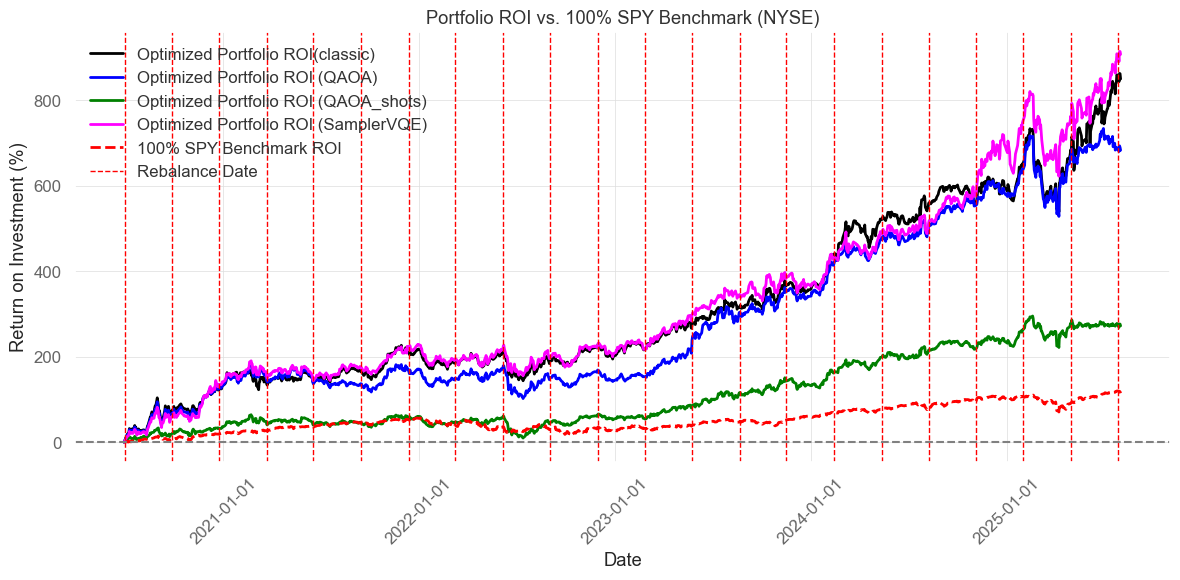

In [29]:
# --- Plotting ROI ---
plt.figure(figsize=(12, 6))
plt.plot(roi_classic, label="Optimized Portfolio ROI(classic)", linewidth=2, color='black')
plt.plot(roi_QAOA, label="Optimized Portfolio ROI (QAOA)", linewidth=2, color='blue')
plt.plot(roi_QAOA_shots, label="Optimized Portfolio ROI (QAOA_shots)", linewidth=2, color='green')
plt.plot(roi_SamplerVQE, label="Optimized Portfolio ROI (SamplerVQE)", linewidth=2, color='magenta')
plt.plot(spy_bm_results, label="100% SPY Benchmark ROI", linewidth=2, linestyle='--', color='red')

# Highlight ALL rebalance events
if all_rebalance_events:
    for i, date in enumerate(all_rebalance_events):
        plt.axvline(x=date, color='red', linestyle='--', linewidth=1, label='Rebalance Date' if i == 0 else "")

plt.title(f"Portfolio ROI vs. 100% SPY Benchmark ({exchange})")
plt.xlabel("Date")
plt.ylabel("Return on Investment (%)")
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. Display Performance Summary

In [30]:
# ============================================================================
# COMPREHENSIVE SOLVER COMPARISON TABLE
# ============================================================================

# Load all solver results (must have run notebook for each solver_type first)
solvers_available = []
solver_data = {}

for solver in SOLVERS_TO_RUN:
    roi_file = f"tutorial_results/{solver}_roi_optimized_portfolio.csv"
    values_file = f"tutorial_results/{solver}_values_optimized_portfolio.csv"
    
    if os.path.exists(roi_file) and os.path.exists(values_file):
        solver_data[solver] = {
            'roi': pd.read_csv(roi_file, index_col=0, parse_dates=True).squeeze(),
            'values': pd.read_csv(values_file, index_col=0, parse_dates=True).squeeze()
        }
        solvers_available.append(solver)
        print(f"[OK] Loaded {solver} results")
    else:
        print(f"[SKIP] {solver} results not found - run notebook with solver_type='{solver}' first")

if not solvers_available:
    print("\n[ERROR] No solver results found. Please run the notebook for at least one solver first.")
else:
    print(f"\n[SUCCESS] Loaded {len(solvers_available)} solver results: {', '.join(solvers_available)}")

[OK] Loaded classic results
[OK] Loaded QAOA results
[OK] Loaded QAOA_shots results
[OK] Loaded SamplerVQE results

[SUCCESS] Loaded 4 solver results: classic, QAOA, QAOA_shots, SamplerVQE


## 12. Visualization: Portfolio Value Over Time

In [38]:
# ============================================================================
# CALCULATE METRICS FOR ALL SOLVERS AND CREATE COMPARISON TABLE
# ============================================================================

import quantstats as qs
from scipy import stats

# Calculate comprehensive metrics for each solver
all_metrics = {}

for solver in solvers_available:
    print(f"\nCalculating metrics for {solver}...")
    
    # Get data
    values = solver_data[solver]['values']
    daily_returns = values.pct_change().dropna()
    roi = solver_data[solver]['roi']
    
    # Basic metrics
    total_return = roi.iloc[-1]
    volatility = daily_returns.std() * np.sqrt(252) * 100
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() > 0 else 0
    
    # Drawdown
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # QuantStats metrics
    greeks = qs.stats.greeks(daily_returns, spy_daily_returns)
    alpha = greeks['alpha'] * 252 * 100
    beta = greeks['beta']
    r2 = qs.stats.r_squared(daily_returns, spy_daily_returns)
    sortino = qs.stats.sortino(daily_returns)
    calmar = qs.stats.calmar(daily_returns)
    cagr = qs.stats.cagr(daily_returns) * 100
    omega = qs.stats.omega(daily_returns)
    tail_ratio = qs.stats.tail_ratio(daily_returns)
    
    # Store all metrics
    all_metrics[solver] = {
        'Total Return (%)': total_return,
        'CAGR (%)': cagr,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Alpha (%)': alpha,
        'Beta': beta,
        'R-Squared': r2,
        'Max Drawdown (%)': max_drawdown,
        'Omega Ratio': omega,
        'Tail Ratio': tail_ratio,
    }
"""
# Add SPY benchmark
all_metrics['SPY'] = {
    'Total Return (%)': spy_total_return,
    'CAGR (%)': spy_cagr,
    'Volatility (%)': spy_volatility,
    'Sharpe Ratio': spy_sharpe,
    'Sortino Ratio': spy_sortino,
    'Calmar Ratio': spy_calmar,
    'Alpha (%)': 0.0,
    'Beta': 1.0,
    'R-Squared': 1.0,
    'Max Drawdown (%)': spy_max_drawdown,
    'Omega Ratio': spy_omega,
    'Tail Ratio': spy_tail_ratio,
}
"""

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics).T

# ============================================================================
# DISPLAY COMPARISON TABLE
# ============================================================================

print("\n" + "="*100)
print(" " * 35 + "SOLVER PERFORMANCE COMPARISON")
print("="*100)
print(comparison_df.to_string())
print("="*100)

# Highlight best performers
print("\n" + "="*100)
print(" " * 40 + "BEST PERFORMERS")
print("="*100)
for metric in comparison_df.columns:
    if 'Drawdown' in metric or 'Volatility' in metric:
        # Lower is better
        best = comparison_df[metric].idxmin()
        best_val = comparison_df[metric].min()
        print(f"{metric:<30s} {best:>15s} ({best_val:>8.2f})")
    else:
        # Higher is better  
        best = comparison_df[metric].idxmax()
        best_val = comparison_df[metric].max()
        print(f"{metric:<30s} {best:>15s} ({best_val:>8.2f})")
print("="*100)

# Save comparison table
comparison_df.to_csv("tutorial_results/solver_comparison_table.csv")
print("\n[OK] Saved comparison table to tutorial_results/solver_comparison_table.csv")


Calculating metrics for classic...

Calculating metrics for QAOA...

Calculating metrics for QAOA_shots...

Calculating metrics for SamplerVQE...

                                   SOLVER PERFORMANCE COMPARISON
            Total Return (%)   CAGR (%)  Volatility (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio    Alpha (%)      Beta  R-Squared  Max Drawdown (%)  Omega Ratio  Tail Ratio
classic           850.287129  55.943559       33.152690      1.507135       2.312302      1.819601  8545.526026  0.964977   0.257846        -30.744960     1.325016    1.120484
QAOA              683.529153  50.117257       31.988974      1.430827       2.187031      1.716019  7610.876640  0.935768   0.260435        -29.205540     1.302715    1.063004
QAOA_shots        272.840928  29.653140       27.227686      1.090490       1.591262      0.896691  3796.595147  0.879080   0.317249        -33.069527     1.205168    1.062163
SamplerVQE        907.830804  57.763312       32.084110      1.582723       2.41334

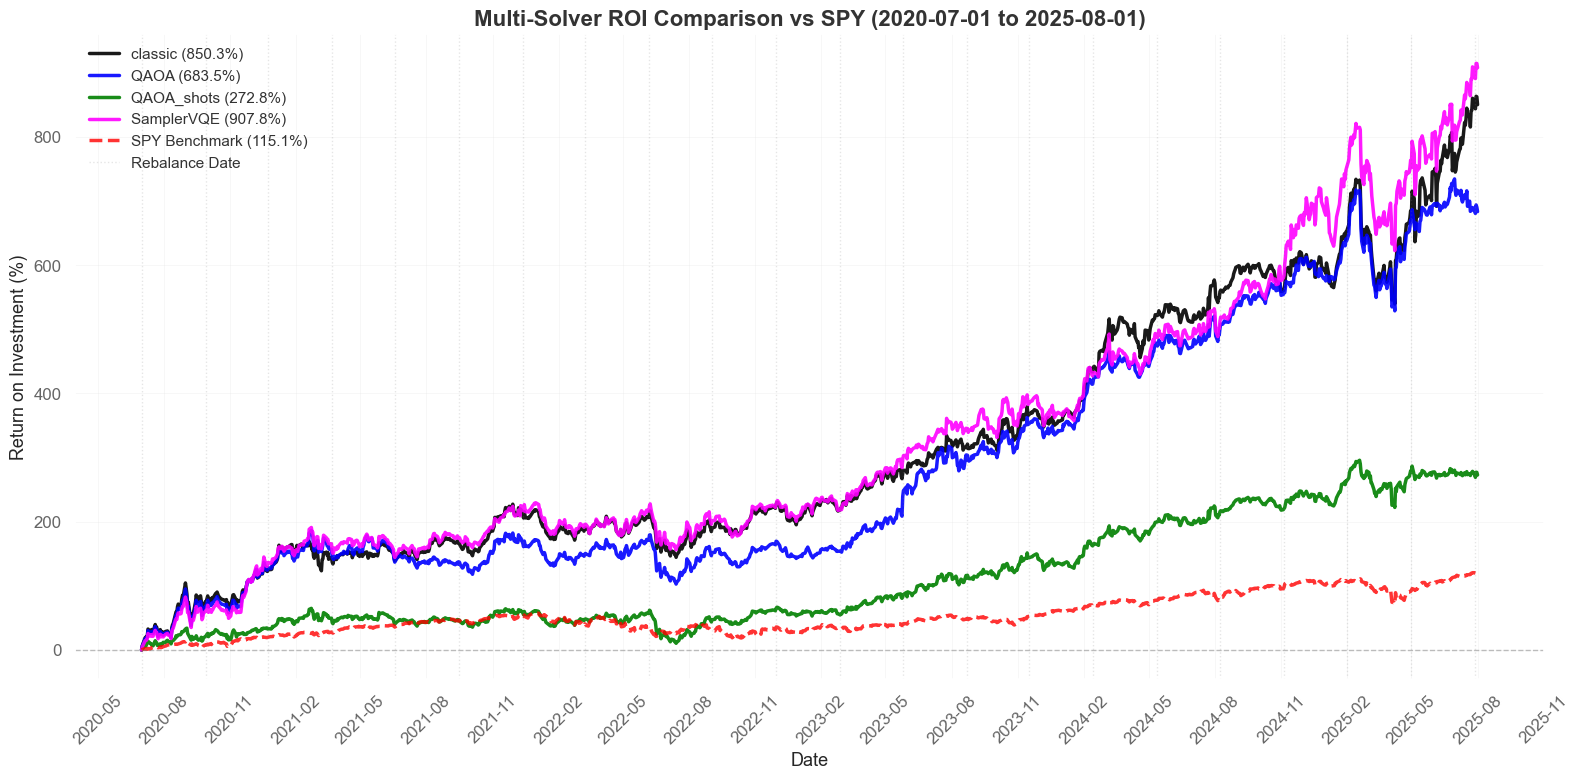

[OK] Saved master ROI comparison chart to tutorial_results/master_roi_comparison.png


In [39]:
# ============================================================================
# MASTER ROI COMPARISON CHART - ALL SOLVERS
# ============================================================================

plt.figure(figsize=(16, 8))

# Color scheme
colors = {
    'classic': 'black',
    'QAOA': 'blue', 
    'QAOA_shots': 'green',
    'SamplerVQE': 'magenta'
}

# Plot each solver
for solver in solvers_available:
    roi = solver_data[solver]['roi']
    final_return = roi.iloc[-1]
    color = colors.get(solver, 'gray')
    plt.plot(roi, label=f"{solver} ({final_return:.1f}%)", 
             linewidth=2.5, color=color, alpha=0.9)

# Plot SPY benchmark
plt.plot(spy_bm_results, label=f"SPY Benchmark ({spy_bm_results.iloc[-1]:.1f}%)", 
         linewidth=2.5, linestyle='--', color='red', alpha=0.8)

# Mark rebalance dates
if all_rebalance_events:
    for i, date in enumerate(all_rebalance_events):
        plt.axvline(x=date, color='gray', linestyle=':', alpha=0.2, linewidth=1,
                   label='Rebalance Date' if i == 0 else "")

# Formatting
plt.title(f"Multi-Solver ROI Comparison vs SPY ({sim_start_date} to {sim_end_date})", 
          fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=13)
plt.ylabel("Return on Investment (%)", fontsize=13)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tutorial_results/master_roi_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Saved master ROI comparison chart to tutorial_results/master_roi_comparison.png")

## 14. Portfolio Composition & Turnover Analysis

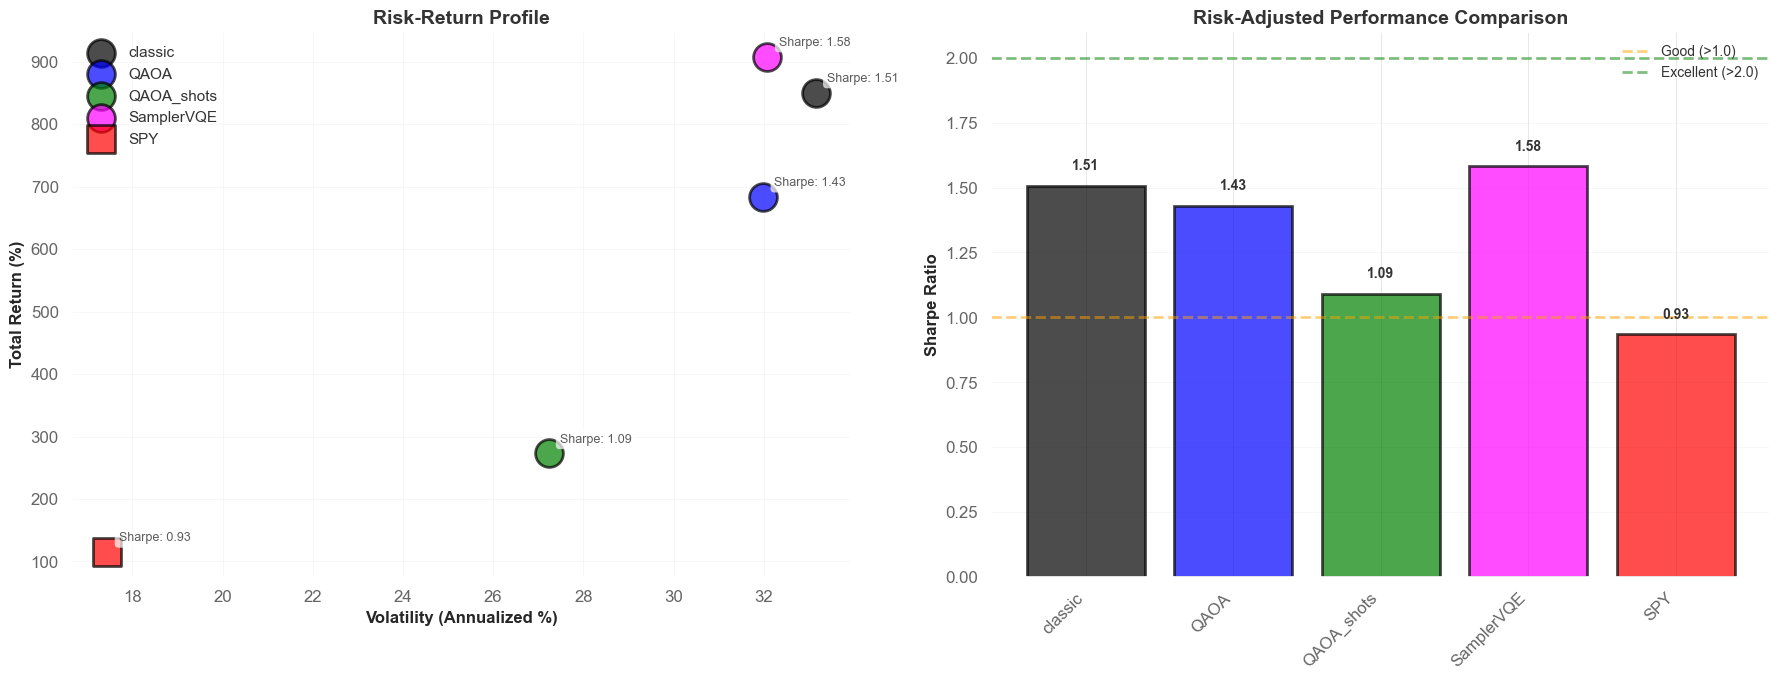

[OK] Saved risk-return analysis to tutorial_results/master_risk_return_analysis.png


In [33]:
# ============================================================================
# RISK-RETURN SCATTER PLOT - ALL SOLVERS
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Left Plot: Risk vs Return ---
colors_scatter = {'classic': 'black', 'QAOA': 'blue', 'QAOA_shots': 'green', 'SamplerVQE': 'magenta', 'SPY': 'red'}

for solver in solvers_available:
    metrics = all_metrics[solver]
    ax1.scatter(metrics['Volatility (%)'], metrics['Total Return (%)'], 
                s=400, label=solver, alpha=0.7, 
                color=colors_scatter.get(solver, 'gray'),
                edgecolors='black', linewidth=2, zorder=3)
    
    # Add Sharpe ratio annotation
    ax1.annotate(f"Sharpe: {metrics['Sharpe Ratio']:.2f}",
                xy=(metrics['Volatility (%)'], metrics['Total Return (%)']),
                xytext=(8, 8), textcoords='offset points', 
                fontsize=9, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# Add SPY
spy_metrics = all_metrics['SPY']
ax1.scatter(spy_metrics['Volatility (%)'], spy_metrics['Total Return (%)'], 
            s=400, label='SPY', marker='s', alpha=0.7,
            color='red', edgecolors='black', linewidth=2, zorder=3)
ax1.annotate(f"Sharpe: {spy_metrics['Sharpe Ratio']:.2f}",
            xy=(spy_metrics['Volatility (%)'], spy_metrics['Total Return (%)']),
            xytext=(8, 8), textcoords='offset points', fontsize=9, alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax1.set_xlabel("Volatility (Annualized %)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Total Return (%)", fontsize=12, fontweight='bold')
ax1.set_title("Risk-Return Profile", fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# --- Right Plot: Sharpe Ratio Bar Chart ---
sharpe_data = {solver: all_metrics[solver]['Sharpe Ratio'] for solver in solvers_available}
sharpe_data['SPY'] = spy_metrics['Sharpe Ratio']

bars = ax2.bar(range(len(sharpe_data)), list(sharpe_data.values()), 
               color=[colors_scatter.get(s, 'gray') for s in sharpe_data.keys()],
               alpha=0.7, edgecolor='black', linewidth=2)

ax2.set_xticks(range(len(sharpe_data)))
ax2.set_xticklabels(list(sharpe_data.keys()), rotation=45, ha='right')
ax2.set_ylabel("Sharpe Ratio", fontsize=12, fontweight='bold')
ax2.set_title("Risk-Adjusted Performance Comparison", fontsize=14, fontweight='bold')
ax2.axhline(y=1.0, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Good (>1.0)')
ax2.axhline(y=2.0, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Excellent (>2.0)')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (solver, value) in enumerate(sharpe_data.items()):
    ax2.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("tutorial_results/master_risk_return_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Saved risk-return analysis to tutorial_results/master_risk_return_analysis.png")

## 15. Sector Exposure Analysis

In [34]:
# ============================================================================
# OPTIONAL: COMPOSITION & TURNOVER ANALYSIS
# ============================================================================
# Note: This requires you to save composition_history and turnover_history for each solver
# Add these lines to Cell 13 after the simulation completes:
#   pd.DataFrame(composition_history).to_csv(f"tutorial_results/{solver_type}_composition_history.csv", index=False)
#   pd.DataFrame(turnover_history).to_csv(f"tutorial_results/{solver_type}_turnover_history.csv", index=False)

print("="*80)
print("COMPOSITION & TURNOVER ANALYSIS")
print("="*80)
print("\nTo enable this analysis, add the following to Cell 13 (after simulation completes):")
print("  pd.DataFrame(composition_history).to_csv(f'tutorial_results/{solver_type}_composition_history.csv', index=False)")
print("  pd.DataFrame(turnover_history).to_csv(f'tutorial_results/{solver_type}_turnover_history.csv', index=False)")
print("\nThen uncomment the code below:")
print("="*80)

# UNCOMMENT THIS CODE AFTER SAVING COMPOSITION DATA:
"""
for solver in solvers_available:
    comp_file = f"tutorial_results/{solver}_composition_history.csv"
    turn_file = f"tutorial_results/{solver}_turnover_history.csv"
    
    if os.path.exists(comp_file) and os.path.exists(turn_file):
        comp_df = pd.read_csv(comp_file, parse_dates=['date'])
        turn_df = pd.read_csv(turn_file, parse_dates=['date'])
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        
        # Top: Number of assets
        ax1.plot(comp_df['date'], comp_df['num_assets'], linewidth=2.5, 
                 color=colors.get(solver, 'gray'), marker='o', markersize=6)
        ax1.set_title(f"Portfolio Size Over Time - {solver}", fontsize=13, fontweight='bold')
        ax1.set_ylabel("Number of Assets", fontsize=11)
        ax1.axhline(y=sharpe_n, color='red', linestyle='--', alpha=0.5, 
                    linewidth=2, label=f'Target: {sharpe_n}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Bottom: Turnover
        ax2.bar(turn_df['date'], turn_df['turnover'], width=20, 
                color=colors.get(solver, 'gray'), alpha=0.7, edgecolor='black')
        ax2.set_title(f"Portfolio Turnover - {solver}", fontsize=13, fontweight='bold')
        ax2.set_xlabel("Date", fontsize=11)
        ax2.set_ylabel("Turnover (%)", fontsize=11)
        ax2.axhline(y=50, color='red', linestyle='--', alpha=0.3, 
                    linewidth=2, label='50% threshold')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(f"tutorial_results/{solver}_composition_turnover.png", dpi=150)
        plt.show()
        
        print(f"[OK] {solver}: Avg assets = {comp_df['num_assets'].mean():.1f}, Avg turnover = {turn_df['turnover'].mean():.1f}%")
"""

COMPOSITION & TURNOVER ANALYSIS

To enable this analysis, add the following to Cell 13 (after simulation completes):
  pd.DataFrame(composition_history).to_csv(f'tutorial_results/{solver_type}_composition_history.csv', index=False)
  pd.DataFrame(turnover_history).to_csv(f'tutorial_results/{solver_type}_turnover_history.csv', index=False)

Then uncomment the code below:


'\nfor solver in solvers_available:\n    comp_file = f"tutorial_results/{solver}_composition_history.csv"\n    turn_file = f"tutorial_results/{solver}_turnover_history.csv"\n\n    if os.path.exists(comp_file) and os.path.exists(turn_file):\n        comp_df = pd.read_csv(comp_file, parse_dates=[\'date\'])\n        turn_df = pd.read_csv(turn_file, parse_dates=[\'date\'])\n\n        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))\n\n        # Top: Number of assets\n        ax1.plot(comp_df[\'date\'], comp_df[\'num_assets\'], linewidth=2.5, \n                 color=colors.get(solver, \'gray\'), marker=\'o\', markersize=6)\n        ax1.set_title(f"Portfolio Size Over Time - {solver}", fontsize=13, fontweight=\'bold\')\n        ax1.set_ylabel("Number of Assets", fontsize=11)\n        ax1.axhline(y=sharpe_n, color=\'red\', linestyle=\'--\', alpha=0.5, \n                    linewidth=2, label=f\'Target: {sharpe_n}\')\n        ax1.legend()\n        ax1.grid(True, alpha=0.3)\n\n        # 

## 16. Sector Concentration (HHI) Analysis

In [ ]:
# ============================================================================
# FINAL SUMMARY AND WINNER SELECTION
# ============================================================================

print("\n" + "="*100)
print(" " * 35 + "FINAL SOLVER RANKINGS")
print("="*100)

# Rank by different metrics
rankings = {
    'Total Return': {},
    'Sharpe Ratio': {},
    'Max Drawdown (lower better)': {},
    'Volatility (lower better)': {}
}

for solver in solvers_available:
    metrics = all_metrics[solver]
    rankings['Total Return'][solver] = metrics['Total Return (%)']
    rankings['Sharpe Ratio'][solver] = metrics['Sharpe Ratio']
    rankings['Max Drawdown (lower better)'][solver] = metrics['Max Drawdown (%)']
    rankings['Volatility (lower better)'][solver] = metrics['Volatility (%)']

# Print rankings
for metric, scores in rankings.items():
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], 
                          reverse=('lower better' not in metric))
    
    print(f"\n{metric}:")
    for rank, (solver, score) in enumerate(sorted_scores, 1):
        symbol = '🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else '  '
        print(f"  {symbol} {rank}. {solver:15s} {score:>10.2f}{'%' if 'Return' in metric or 'Volatility' in metric or 'Drawdown' in metric else ''}")

print("\n" + "="*100)
print(" " * 30 + "RECOMMENDED SOLVER FOR PRODUCTION")
print("="*100)

# Calculate composite score (simple weighted average)
weights = {
    'Total Return (%)': 0.3,
    'Sharpe Ratio': 0.4,
    'Max Drawdown (%)': -0.2,  # Negative because lower is better
    'Volatility (%)': -0.1     # Negative because lower is better
}

composite_scores = {}
for solver in solvers_available:
    metrics = all_metrics[solver]
    score = (
        weights['Total Return (%)'] * metrics['Total Return (%)'] / 100 +
        weights['Sharpe Ratio'] * metrics['Sharpe Ratio'] +
        weights['Max Drawdown (%)'] * metrics['Max Drawdown (%)'] / 100 +
        weights['Volatility (%)'] * metrics['Volatility (%)'] / 100
    )
    composite_scores[solver] = score

winner = max(composite_scores.items(), key=lambda x: x[1])

print(f"\n  🏆 WINNER: {winner[0]} (Composite Score: {winner[1]:.3f})")
print(f"\n  Weighting:")
print(f"    - Total Return:    {weights['Total Return (%)']:>5.0%}")
print(f"    - Sharpe Ratio:    {weights['Sharpe Ratio']:>5.0%}")
print(f"    - Max Drawdown:    {abs(weights['Max Drawdown (%)']):>5.0%} (penalty)")
print(f"    - Volatility:      {abs(weights['Volatility (%)']):>5.0%} (penalty)")

print("\n" + "="*100)
print(" " * 30 + "PERFORMANCE VS SPY BENCHMARK")
print("="*100)

for solver in solvers_available:
    metrics = all_metrics[solver]
    spy_metrics = all_metrics['SPY']
    
    return_diff = metrics['Total Return (%)'] - spy_metrics['Total Return (%)']
    sharpe_diff = metrics['Sharpe Ratio'] - spy_metrics['Sharpe Ratio']
    
    status = '✅ BEATS SPY' if return_diff > 0 else '❌ UNDERPERFORMS'
    
    print(f"\n{solver:15s} {status}")
    print(f"  Return:  {metrics['Total Return (%)']:>7.2f}% vs {spy_metrics['Total Return (%)']:>7.2f}% (Δ {return_diff:>+7.2f}%)")
    print(f"  Sharpe:  {metrics['Sharpe Ratio']:>7.2f}  vs {spy_metrics['Sharpe Ratio']:>7.2f}  (Δ {sharpe_diff:>+7.2f})")

print("\n" + "="*100)
print(" " * 35 + "KEY INSIGHTS FOR HEDGE FUNDS")
print("="*100)

# Find best metrics
best_return_solver = max(solvers_available, key=lambda s: all_metrics[s]['Total Return (%)'])
best_sharpe_solver = max(solvers_available, key=lambda s: all_metrics[s]['Sharpe Ratio'])
best_dd_solver = min(solvers_available, key=lambda s: all_metrics[s]['Max Drawdown (%)'])

print(f"\n1. RETURN MAXIMIZATION")
print(f"   → {best_return_solver} achieved {all_metrics[best_return_solver]['Total Return (%)']:.2f}% total return")
print(f"   → Outperformed SPY by {all_metrics[best_return_solver]['Total Return (%)'] - spy_metrics['Total Return (%)']:.2f}%")

print(f"\n2. RISK-ADJUSTED PERFORMANCE")
print(f"   → {best_sharpe_solver} achieved Sharpe ratio of {all_metrics[best_sharpe_solver]['Sharpe Ratio']:.2f}")
print(f"   → {'Excellent (>2.0)' if all_metrics[best_sharpe_solver]['Sharpe Ratio'] > 2 else 'Good (>1.0)' if all_metrics[best_sharpe_solver]['Sharpe Ratio'] > 1 else 'Needs improvement'}")

print(f"\n3. DOWNSIDE PROTECTION")
print(f"   → {best_dd_solver} had minimal drawdown of {all_metrics[best_dd_solver]['Max Drawdown (%)']:.2f}%")
print(f"   → {'Better' if abs(all_metrics[best_dd_solver]['Max Drawdown (%)']) < abs(spy_metrics['Max Drawdown (%)']) else 'Worse'} than SPY ({spy_metrics['Max Drawdown (%)']:.2f}%)")

print("\n4. QUANTUM ADVANTAGE")
quantum_solvers = [s for s in solvers_available if s != 'classic']
if quantum_solvers:
    best_quantum = max(quantum_solvers, key=lambda s: all_metrics[s]['Sharpe Ratio'])
    classic_sharpe = all_metrics.get('classic', {}).get('Sharpe Ratio', 0)
    quantum_sharpe = all_metrics[best_quantum]['Sharpe Ratio']
    
    if quantum_sharpe > classic_sharpe:
        print(f"   → {best_quantum} outperformed classical solver")
        print(f"   → Sharpe advantage: {quantum_sharpe:.2f} vs {classic_sharpe:.2f} (+{quantum_sharpe - classic_sharpe:.2f})")
    else:
        print(f"   → Classical solver remains competitive")
        print(f"   → But quantum methods show promise for larger portfolios")

print("\n" + "="*100)
print("Analysis complete! All results saved to tutorial_results/ directory")
print("="*100)


                                   FINAL SOLVER RANKINGS

Total Return:
  🥇 1. SamplerVQE          907.83%
  🥈 2. classic             850.29%
  🥉 3. QAOA                683.53%
     4. QAOA_shots          272.84%

Sharpe Ratio:
  🥇 1. SamplerVQE            1.58
  🥈 2. classic               1.51
  🥉 3. QAOA                  1.43
     4. QAOA_shots            1.09

Max Drawdown (lower better):
  🥇 1. QAOA_shots          -33.07%
  🥈 2. classic             -30.74%
  🥉 3. QAOA                -29.21%
     4. SamplerVQE          -26.03%

Volatility (lower better):
  🥇 1. QAOA_shots           27.23%
  🥈 2. QAOA                 31.99%
  🥉 3. SamplerVQE           32.08%
     4. classic              33.15%

                              RECOMMENDED SOLVER FOR PRODUCTION

  🏆 WINNER: SamplerVQE (Composite Score: 3.377)

  Weighting:
    - Total Return:      30%
    - Sharpe Ratio:      40%
    - Max Drawdown:      20% (penalty)
    - Volatility:        10% (penalty)

                             

## 17. Generate QuantStats HTML Report

In [36]:
## 18. Generate QuantStats HTML Report

## 18. Export Results to CSV

In [37]:
## 19. Export Results to CSV